
# Tesla Deliveries ML Pipeline (2015–2025)

This notebook contains:

1. Data Loading & Inspection  
2. Exploratory Data Analysis (EDA)  
3. Feature Engineering  
4. Leakage Prevention  
5. Regression Modeling  
6. Hyperparameter Tuning  
7. Time Series Forecasting  
8. Forecast Visualization & Export  


In [18]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor


## Load Dataset

In [19]:

df = pd.read_csv(
    "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
)

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Initial Inspection

In [20]:

print("Shape:", df.shape)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nData Types:\n")
print(df.dtypes)


Shape: (2640, 12)

Missing Values:

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Data Types:

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


## Datetime Processing

In [21]:

df["Date"] = pd.to_datetime(
    dict(year=df["Year"], month=df["Month"], day=1)
)

df = df.sort_values("Date").reset_index(drop=True)

TARGET = "Estimated_Deliveries"

df[["Date", TARGET]].head()


,Date,Estimated_Deliveries
0,2015-01-01,12446
1,2015-01-01,11446
2,2015-01-01,8803
3,2015-01-01,6367
4,2015-01-01,8795


## Exploratory Data Analysis (EDA)

In [22]:

df.describe()


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712,2020-06-16 02:10:54.545454592
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000,2015-01-01 00:00:00
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000,2017-09-23 12:00:00
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000,2020-06-16 00:00:00
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000,2023-03-08 18:00:00
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000,2025-12-01 00:00:00
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883,NaN


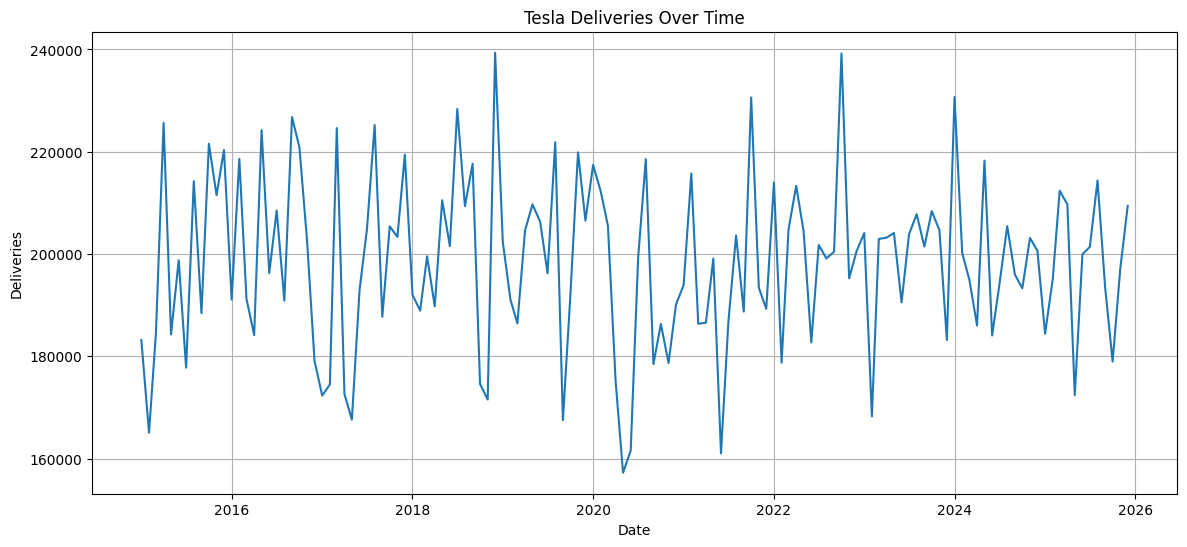

In [23]:

monthly_sales = (
    df.groupby("Date")[TARGET]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales["Date"], monthly_sales[TARGET])
plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.grid(True)
plt.show()


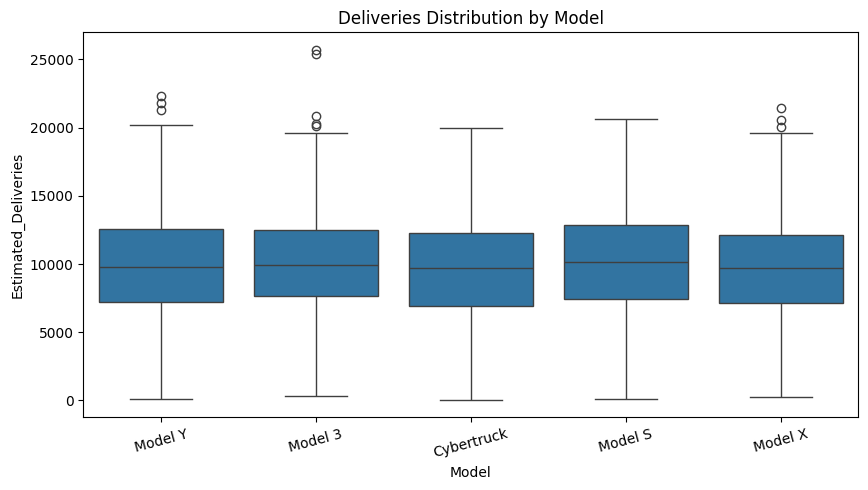

In [24]:

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Model", y=TARGET)
plt.title("Deliveries Distribution by Model")
plt.xticks(rotation=15)
plt.show()


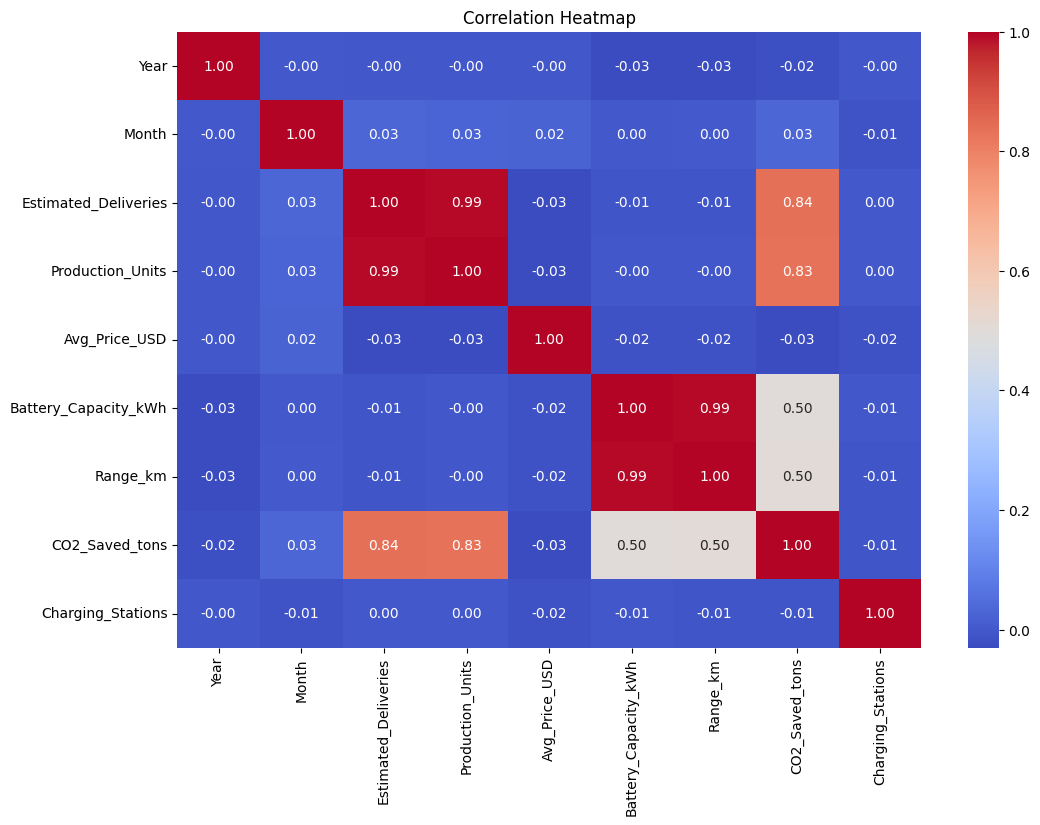

In [25]:

numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()


## Feature Engineering

In [26]:

df["Quarter"] = df["Date"].dt.quarter
df["Month_Sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_Cos"] = np.cos(2 * np.pi * df["Month"] / 12)

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_Sin,Month_Cos
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,0.5,0.866025
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,0.5,0.866025
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,0.5,0.866025
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,0.5,0.866025
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,0.5,0.866025



## Leakage Prevention

Lag features and rolling statistics use only historical data.
No future observations are used during training.


In [27]:

monthly_ts = (
    df.groupby("Date")[TARGET]
    .sum()
    .reset_index()
    .sort_values("Date")
)

monthly_ts["Lag_1"] = monthly_ts[TARGET].shift(1)
monthly_ts["Lag_3"] = monthly_ts[TARGET].shift(3)

monthly_ts["Rolling_Mean_3"] = (
    monthly_ts[TARGET]
    .shift(1)
    .rolling(window=3)
    .mean()
)

monthly_ts.head()


,Date,Estimated_Deliveries,Lag_1,Lag_3,Rolling_Mean_3
0,2015-01-01,183180,NaN,NaN,NaN
1,2015-02-01,165053,183180.0,NaN,NaN
2,2015-03-01,184567,165053.0,NaN,NaN
3,2015-04-01,225623,184567.0,183180.0,177600.000000
4,2015-05-01,184264,225623.0,165053.0,191747.666667


In [28]:

df = df.merge(
    monthly_ts[
        ["Date", "Lag_1", "Lag_3", "Rolling_Mean_3"]
    ],
    on="Date",
    how="left"
)

df = df.dropna().reset_index(drop=True)

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_Sin,Month_Cos,Lag_1,Lag_3,Rolling_Mean_3
0,2015,4,Middle East,Model 3,10387,11371,81391.19,120,677,1054.80,Estimated (Region),6943,2015-04-01,2,0.866025,-0.5,184567.0,183180.0,177600.0
1,2015,4,Asia,Model 3,11229,12493,106478.43,82,491,827.02,Official (Quarter),7951,2015-04-01,2,0.866025,-0.5,184567.0,183180.0,177600.0
2,2015,4,North America,Model 3,14129,14159,58125.08,120,662,1403.01,Official (Quarter),3488,2015-04-01,2,0.866025,-0.5,184567.0,183180.0,177600.0
3,2015,4,Middle East,Model Y,9951,10036,88467.02,60,343,511.98,Estimated (Region),13652,2015-04-01,2,0.866025,-0.5,184567.0,183180.0,177600.0
4,2015,4,North America,Model Y,13098,13438,80369.62,60,341,669.96,Interpolated (Month),10390,2015-04-01,2,0.866025,-0.5,184567.0,183180.0,177600.0


## Feature Selection

In [29]:

features = [
    "Region",
    "Model",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Source_Type",
    "Charging_Stations",
    "Quarter",
    "Month_Sin",
    "Month_Cos",
    "Lag_1",
    "Lag_3",
    "Rolling_Mean_3"
]

X = df[features]
y = df[TARGET]

X.head()


,Region,Model,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter,Month_Sin,Month_Cos,Lag_1,Lag_3,Rolling_Mean_3
0,Middle East,Model 3,11371,81391.19,120,677,1054.80,Estimated (Region),6943,2,0.866025,-0.5,184567.0,183180.0,177600.0
1,Asia,Model 3,12493,106478.43,82,491,827.02,Official (Quarter),7951,2,0.866025,-0.5,184567.0,183180.0,177600.0
2,North America,Model 3,14159,58125.08,120,662,1403.01,Official (Quarter),3488,2,0.866025,-0.5,184567.0,183180.0,177600.0
3,Middle East,Model Y,10036,88467.02,60,343,511.98,Estimated (Region),13652,2,0.866025,-0.5,184567.0,183180.0,177600.0
4,North America,Model Y,13438,80369.62,60,341,669.96,Interpolated (Month),10390,2,0.866025,-0.5,184567.0,183180.0,177600.0


## Chronological Train-Test Split

In [30]:

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Size:", X_train.shape)
print("Testing Size :", X_test.shape)


Training Size: (2064, 15)
Testing Size : (516, 15)


## Preprocessing Pipeline

In [31]:

categorical_features = [
    "Region",
    "Model",
    "Source_Type"
]

numeric_features = [
    col for col in features
    if col not in categorical_features
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Production_Units', 'Avg_Price_USD',
                                  'Battery_Capacity_kWh', 'Range_km',
                                  'CO2_Saved_tons', 'Charging_Stations',
                                  'Quarter', 'Month_Sin', 'Month_Cos', 'Lag_1',
                                  'Lag_3', 'Rolling_Mean_3']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Region', 'Model', 'Source_Type'])])

## Baseline Model

In [45]:

baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42
    ))
])

baseline_pipeline.fit(X_train, y_train)

baseline_preds = baseline_pipeline.predict(X_test)

print("MAE :", mean_absolute_error(y_test, baseline_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, baseline_preds)))


MAE : 329.82606589147287
RMSE: 407.0634847095901


## Hyperparameter Tuning with TimeSeriesSplit

In [33]:

tscv = TimeSeriesSplit(n_splits=5)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print(search.best_params_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}


## Final Model Evaluation

In [34]:

final_preds = best_model.predict(X_test)

mae = mean_absolute_error(y_test, final_preds)
rmse = np.sqrt(mean_squared_error(y_test, final_preds))
r2 = r2_score(y_test, final_preds)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")


MAE  : 267.61
RMSE : 335.03
R2   : 0.9916


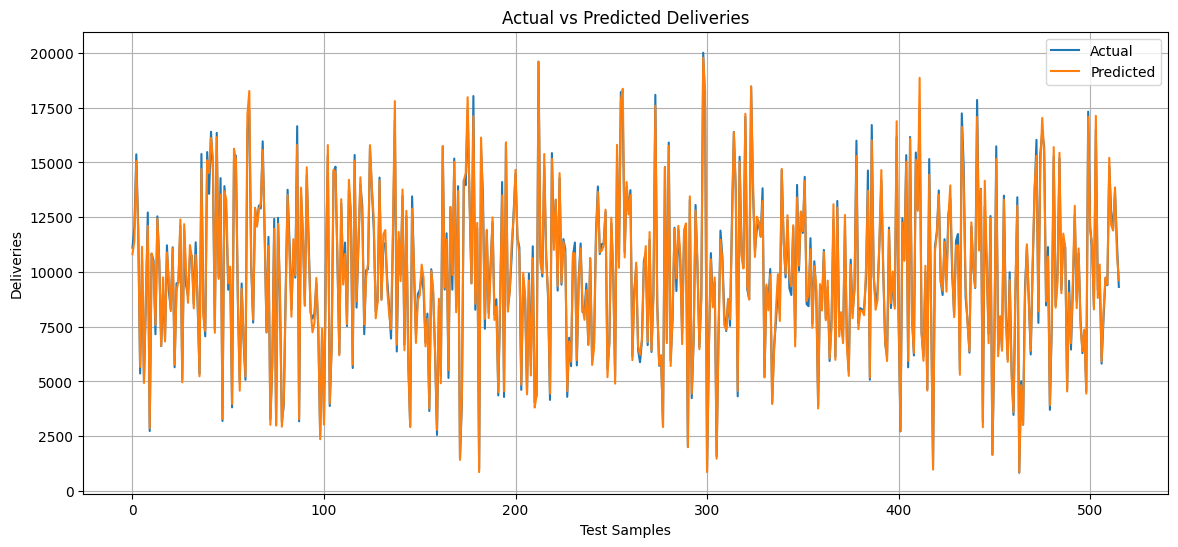

In [35]:

results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_preds
})

plt.figure(figsize=(14, 6))
plt.plot(results_df["Actual"].values, label="Actual")
plt.plot(results_df["Predicted"].values, label="Predicted")
plt.title("Actual vs Predicted Deliveries")
plt.xlabel("Test Samples")
plt.ylabel("Deliveries")
plt.legend()
plt.grid(True)
plt.show()


## Feature Importance

In [36]:

ohe = best_model.named_steps["preprocessor"]     .named_transformers_["cat"]     .named_steps["onehot"]

encoded_cat_features = ohe.get_feature_names_out(categorical_features)

all_feature_names = (
    numeric_features +
    list(encoded_cat_features)
)

importances = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)


,Feature,Importance
0,Production_Units,0.954189
4,CO2_Saved_tons,0.004489
3,Range_km,0.004394
8,Month_Cos,0.003444
20,Model_Model Y,0.003441
2,Battery_Capacity_kWh,0.002251
15,Region_North America,0.002238
10,Lag_3,0.001965
12,Region_Asia,0.001906
1,Avg_Price_USD,0.001863


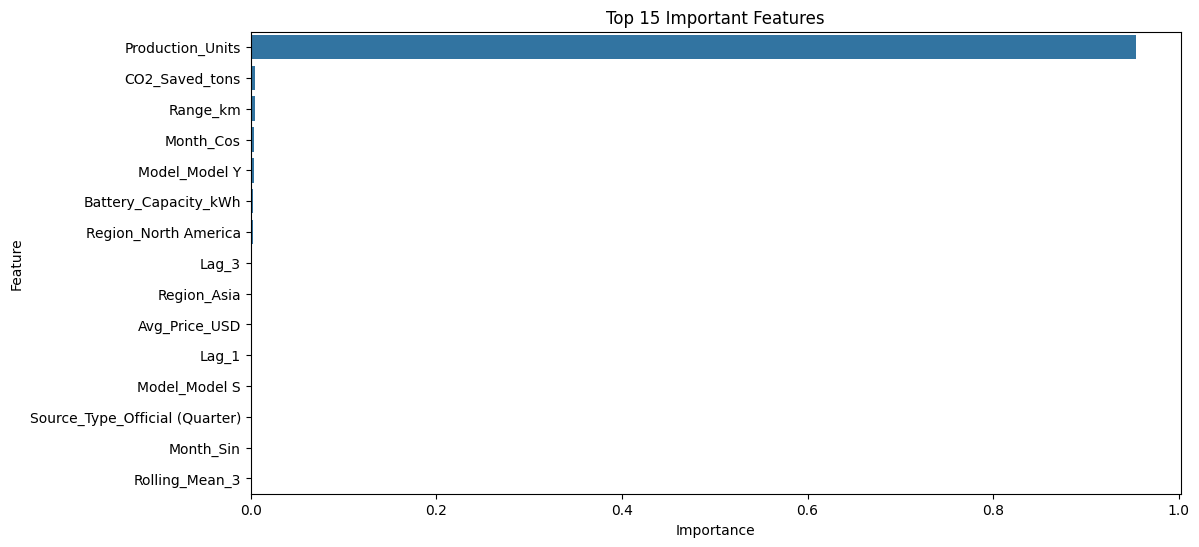

In [37]:

plt.figure(figsize=(12, 6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.show()


## Time Series Forecasting

In [42]:

forecast_df = monthly_ts.dropna().copy()

forecast_features = [
    "Lag_1",
    "Lag_3",
    "Rolling_Mean_3"
]

X_forecast = forecast_df[forecast_features]
y_forecast = forecast_df[TARGET]

split_ts = int(len(forecast_df) * 0.8)

Xf_train = X_forecast.iloc[:split_ts]
Xf_test = X_forecast.iloc[split_ts:]

yf_train = y_forecast.iloc[:split_ts]
yf_test = y_forecast.iloc[split_ts:]

forecast_model = GradientBoostingRegressor(random_state=42)

forecast_model.fit(Xf_train, yf_train)

forecast_preds = forecast_model.predict(Xf_test)

print("MAE :", mean_absolute_error(yf_test, forecast_preds))
print("RMSE:", np.sqrt(mean_squared_error(yf_test, forecast_preds)))


MAE : 12203.970212939192
RMSE: 15743.145015485823


## Future 6-Month Forecast

In [43]:

future_predictions = []

history = forecast_df.copy()

for step in range(6):

    latest_row = history.iloc[-1]

    next_lag_1 = latest_row[TARGET]
    next_lag_3 = history.iloc[-3][TARGET]

    next_rolling = (
        history[TARGET]
        .tail(3)
        .mean()
    )

    future_X = pd.DataFrame({
        "Lag_1": [next_lag_1],
        "Lag_3": [next_lag_3],
        "Rolling_Mean_3": [next_rolling]
    })

    next_prediction = forecast_model.predict(future_X)[0]

    future_predictions.append(next_prediction)

    next_date = latest_row["Date"] + pd.DateOffset(months=1)

    new_row = {
        "Date": next_date,
        TARGET: next_prediction,
        "Lag_1": next_lag_1,
        "Lag_3": next_lag_3,
        "Rolling_Mean_3": next_rolling
    }

    history = pd.concat(
        [history, pd.DataFrame([new_row])],
        ignore_index=True
    )

future_dates = pd.date_range(
    start=history["Date"].iloc[-6],
    periods=6,
    freq="MS"
)

forecast_output = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Deliveries": future_predictions
})

forecast_output


,Date,Forecasted_Deliveries
0,2026-01-01,205062.779809
1,2026-02-01,208448.062926
2,2026-03-01,205913.937909
3,2026-04-01,197130.746754
4,2026-05-01,206458.575498
5,2026-06-01,199914.251930


## Forecast Visualization

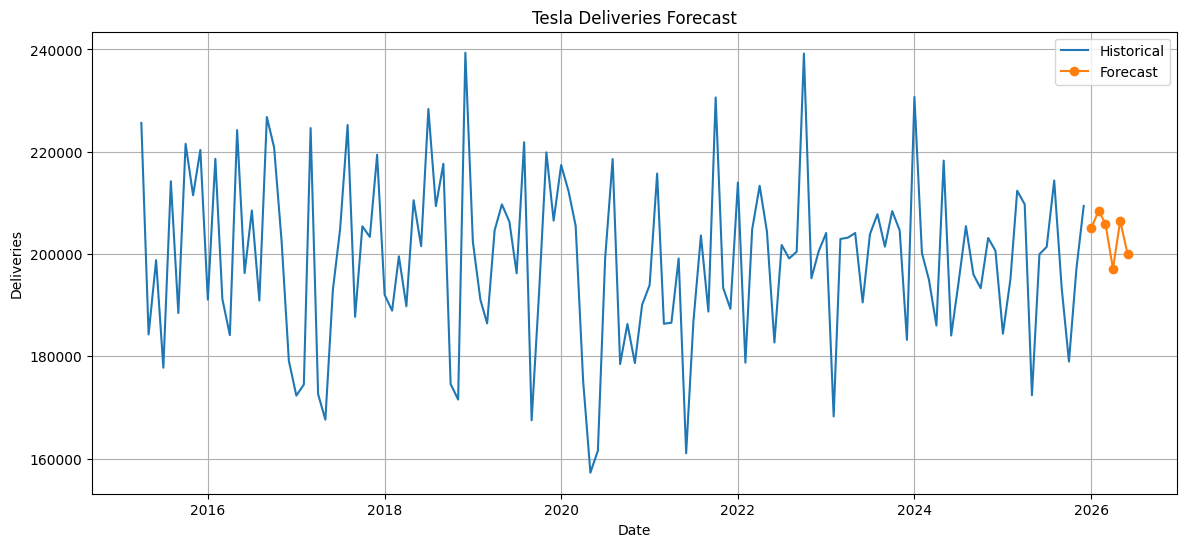

In [44]:

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_df["Date"],
    forecast_df[TARGET],
    label="Historical"
)

plt.plot(
    forecast_output["Date"],
    forecast_output["Forecasted_Deliveries"],
    marker="o",
    label="Forecast"
)

plt.title("Tesla Deliveries Forecast")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.legend()
plt.grid(True)
plt.show()
